In [ ]:
!pip install opendatasets

In [ ]:
#username:abraralmutawa
#key:a8fbb7a52114009212daa035717f25a3
import opendatasets as od
od.download("https://www.kaggle.com/datasets/mohammadtalib786/retail-sales-dataset?select=retail_sales_dataset.csv")

Skipping, found downloaded files in "./retail-sales-dataset" (use force=True to force download)


In [ ]:
#importing libraries

import pandas as pd
import numpy as np


In [ ]:
#pandas DataFrame
df = pd.read_csv("retail-sales-dataset/retail_sales_dataset.csv")
df.head()


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
#numbers of rows
df.shape[0]

1000

In [ ]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [ ]:
# the threshold is the median of the total amount
total_col = 'Total Amount'
threshold = df[total_col].median()
#creating a new column called High_Sale 0 means low 1 means high
df['High_Sale'] = (df[total_col] > threshold).astype(int)

# X features and Y target
X = df.drop(['Transaction ID','Date','Customer ID','Total Amount','High_Sale','Quantity'], axis=1)
Y = df['High_Sale'].values.reshape(-1, 1)



In [ ]:
def one_hot_encode(df):
    df_encoded = pd.DataFrame()

    for col in df.columns:
        if df[col].dtype == "object":
            dummies = pd.get_dummies(df[col], drop_first=True)
            df_encoded = pd.concat([df_encoded, dummies], axis=1)
        else:
            df_encoded[col] = df[col]

    return df_encoded

In [ ]:
X_encoded = one_hot_encode(X)
X_np = X_encoded.values.astype(float)

In [ ]:
def train_test_split(X, Y, test_size=0.2, seed=42):
    np.random.seed(seed)
    indices = np.random.permutation(len(X))
    test_count = int(len(X) * test_size)

    test_idx = indices[:test_count]
    train_idx = indices[test_count:]

    return X[train_idx], X[test_idx], Y[train_idx], Y[test_idx]

X_train, X_test, y_train, y_test = train_test_split(X_np, Y)



In [ ]:
class RidgeClassifier:
    def __init__(self, lr=0.001, epochs=2000, alpha=1.0):
        self.lr = lr
        self.epochs = epochs
        self.alpha = alpha

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros((n_features, 1))
        self.b = 0

        for _ in range(self.epochs):
            linear = np.dot(X, self.w) + self.b
            y_pred = self.sigmoid(linear)

            dw = (1/n_samples) * np.dot(X.T, (y_pred - y)) + (self.alpha * self.w)
            db = (1/n_samples) * np.sum(y_pred - y)

            self.w -= self.lr * dw
            self.b -= self.lr * db

    def predict(self, X):
        linear = np.dot(X, self.w) + self.b
        y_pred = self.sigmoid(linear)
        return (y_pred >= 0.5).astype(int)

ridge_model = RidgeClassifier()
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

In [ ]:
class DecisionTree:
    def __init__(self, max_depth=5):
        self.max_depth = max_depth

    def gini(self, y):
        p1 = np.mean(y == 1)
        p0 = 1 - p1
        return 1 - (p1**2 + p0**2)

    def best_split(self, X, y):
        best_feature, best_value = None, None
        best_gain = -1
        parent_gini = self.gini(y)

        for feature in range(X.shape[1]):
            values = np.unique(X[:, feature])

            for v in values:
                left = y[X[:, feature] <= v]
                right = y[X[:, feature] > v]

                if len(left) == 0 or len(right) == 0:
                    continue

                gini_split = (len(left)/len(y))*self.gini(left) + \
                             (len(right)/len(y))*self.gini(right)

                gain = parent_gini - gini_split

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_value = v

        return best_feature, best_value

    def build_tree(self, X, y, depth=0):
        if depth >= self.max_depth or len(np.unique(y)) == 1:
            return np.round(np.mean(y))

        feat, val = self.best_split(X, y)

        if feat is None:
            return np.round(np.mean(y))

        left_idx = X[:, feat] <= val
        right_idx = X[:, feat] > val

        return {
            "feature": feat,
            "value": val,
            "left": self.build_tree(X[left_idx], y[left_idx], depth+1),
            "right": self.build_tree(X[right_idx], y[right_idx], depth+1)
        }

    def fit(self, X, y):
        self.tree = self.build_tree(X, y.flatten())

    def predict_one(self, x, node):
        if not isinstance(node, dict):
            return node

        if x[node["feature"]] <= node["value"]:
            return self.predict_one(x, node["left"])
        else:
            return self.predict_one(x, node["right"])

    def predict(self, X):
        return np.array([self.predict_one(row, self.tree) for row in X]).reshape(-1, 1).astype(int)

tree_model = DecisionTree(max_depth=5)
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)



In [ ]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)


In [ ]:
def evaluate(name, y_true, y_pred):
    print(f"\n{name} results")
    print(f"Accuracy : {accuracy(y_true, y_pred):.3f}")



In [ ]:
def run_example(title, seed):
    X_train, X_test, y_train, y_test = train_test_split(X_np, Y, test_size=0.25, seed=seed)

    print(f"\n=========== {title} (seed={seed}) ===========\n")

    # Ridge
    ridge = RidgeClassifier()
    ridge.fit(X_train, y_train)
    pred_r = ridge.predict(X_test)
    print("Ridge Accuracy:", accuracy(y_test, pred_r))

    # Tree
    tree = DecisionTree(max_depth=5)
    tree.fit(X_train, y_train)
    pred_t = tree.predict(X_test)
    print("Tree Accuracy:", accuracy(y_test, pred_t))


run_example("Example 1: First Split", seed=1)
run_example("Example 2: Second Split", seed=50)
run_example("Example 3: Third Split", seed=123)




=========== Example 1: First Split (seed=1) ===========

Ridge Accuracy: 0.872
Tree Accuracy: 0.876

=========== Example 2: Second Split (seed=50) ===========

Ridge Accuracy: 0.896
Tree Accuracy: 0.912

=========== Example 3: Third Split (seed=123) ===========

Ridge Accuracy: 0.904
Tree Accuracy: 0.892


In [ ]:
import time


In [ ]:

def measure_time(model_class, X_train, y_train, X_test, runs=20):

    results = []

    for r in range(1, runs + 1):
        start = time.time()

        # Train the model
        model = model_class()
        model.fit(X_train, y_train)

        # Predict
        model.predict(X_test)

        end = time.time()

        exec_time = (end - start) * 1e6  # convert seconds → microseconds

        results.append({
            "Run": r,
            "Execution Time (µs)": exec_time
        })

    return pd.DataFrame(results)


In [ ]:
import numpy as np
import time
import math

small_sizes  = [20, 30, 50, 70]
medium_sizes = [400, 450, 500, 550]
large_sizes  = [750, 850, 950, 1000]

groups = {
    "Small Dataset": small_sizes,
    "Medium Dataset": medium_sizes,
    "Large Dataset": large_sizes
}

def ridge_theoretical(n, d, epochs=500):
    return n * d * epochs

def tree_theoretical(n):
    return n * math.log2(n)

d = X_np.shape[1]  # number of features


def run_20_trials(model_class, X, y, **model_params):
    times = []

    for _ in range(20):
        model = model_class(**model_params)

        start = time.perf_counter()
        model.fit(X, y)
        end = time.perf_counter()

        runtime_us = (end - start) * 1_000_000  # convert seconds → microseconds
        times.append(runtime_us)

    return times

all_results = {}

for group_name, size_list in groups.items():

    print(f"\n\n================= {group_name} =================\n")

    for n in size_list:
        print(f"\n----- Testing with n = {n} samples -----\n")

        # Select first n samples from dataset
        Xn = X_np[:n]
        yn = Y[:n]

        ridge_times = run_20_trials(
            RidgeClassifier,
            Xn,
            yn,
            lr=0.001,
            epochs=500
        )

        all_results[(group_name, n, "Ridge")] = ridge_times

        # summary
        print("Ridge Classifier:")
        print(f"Best:   {np.min(ridge_times):.2f} µs")
        print(f"Avg:    {np.mean(ridge_times):.2f} µs")
        print(f"Worst:  {np.max(ridge_times):.2f} µs\n")

        tree_times = run_20_trials(
            DecisionTree,
            Xn,
            yn.flatten(),
            max_depth=5
        )

        all_results[(group_name, n, "Tree")] = tree_times

        # summary
        print("Decision Tree:")
        print(f"Best:   {np.min(tree_times):.2f} µs")
        print(f"Avg:    {np.mean(tree_times):.2f} µs")
        print(f"Worst:  {np.max(tree_times):.2f} µs\n")




================= Small Dataset =================


----- Testing with n = 20 samples -----

Ridge Classifier:
Best:   13062.67 µs
Avg:    20252.69 µs
Worst:  53116.33 µs

Decision Tree:
Best:   1749.68 µs
Avg:    2187.26 µs
Worst:  2777.77 µs


----- Testing with n = 30 samples -----

Ridge Classifier:
Best:   12985.51 µs
Avg:    14703.55 µs
Worst:  17677.77 µs

Decision Tree:
Best:   2298.95 µs
Avg:    2488.02 µs
Worst:  3184.30 µs


----- Testing with n = 50 samples -----

Ridge Classifier:
Best:   14153.19 µs
Avg:    15786.62 µs
Worst:  31974.03 µs

Decision Tree:
Best:   3170.63 µs
Avg:    3311.16 µs
Worst:  3824.19 µs


----- Testing with n = 70 samples -----

Ridge Classifier:
Best:   14335.19 µs
Avg:    23137.12 µs
Worst:  36542.59 µs

Decision Tree:
Best:   6063.70 µs
Avg:    6915.06 µs
Worst:  8078.27 µs



================= Medium Dataset =================


----- Testing with n = 400 samples -----

Ridge Classifier:
Best:   35344.34 µs
Avg:    37851.66 µs
Worst:  52953.31

In [ ]:
def create_runs_table(group_name, model_name, size_list):

    data = {}

    for n in size_list:
        key = (group_name, n, model_name)
        times = all_results[key]  # list of 20 runtime values
        data[n] = times

    df = pd.DataFrame(data)
    df.index = [f"Time {i}" for i in range(1, 21)]  # Rename rows
    return df


In [ ]:
def create_comparison_table(group_name, model_name, size_list, theory_func):

    rows = []

    for n in size_list:
        key = (group_name, n, model_name)
        times = all_results[key]

        exp_avg = np.mean(times)

        if model_name == "Ridge":
            theory = theory_func(n, d)
        else:
            theory = theory_func(n)

        ratio = exp_avg / theory

        rows.append([
            n,
            round(exp_avg, 3),
            round(theory, 3),
            round(ratio, 6)
        ])

    df = pd.DataFrame(rows, columns=[
        "Input Size (n)",
        "Experimental Average (µs)",
        "Theoretical Estimate (µs)",
        "Experimental/Theoretical"
    ])

    return df


In [ ]:
print("small_ridge_runs")
small_ridge_runs = create_runs_table("Small Dataset", "Ridge", small_sizes)
small_ridge_runs


small_ridge_runs


,20,30,50,70
Time 1,53116.330,15834.632,15074.869,15031.598
Time 2,24100.083,17235.097,14303.687,14396.969
Time 3,15539.413,14618.800,14243.362,14884.127
Time 4,13255.345,15061.254,14153.193,14335.190
Time 5,13062.671,15369.893,14200.145,14500.059
Time 6,16170.511,14767.615,17394.416,14555.073
Time 7,18554.485,16507.516,14538.012,18149.661
Time 8,17015.599,16649.082,14440.108,18796.683
Time 9,18907.078,12985.507,14161.568,22854.854
Time 10,15905.110,14354.706,14487.993,23019.717


In [ ]:
print("\nsmall_ridge_comp")
small_ridge_comp = create_comparison_table("Small Dataset", "Ridge", small_sizes, ridge_theoretical)
small_ridge_comp



small_ridge_comp


,Input Size (n),Experimental Average (µs),Theoretical Estimate (µs),Experimental/Theoretical
0,20,20252.690,50000,0.405054
1,30,14703.554,75000,0.196047
2,50,15786.621,125000,0.126293
3,70,23137.121,175000,0.132212


In [ ]:
print("\nsmall_tree_runs")
small_tree_runs = create_runs_table("Small Dataset", "Tree", small_sizes)
small_tree_runs


small_tree_runs


,20,30,50,70
Time 1,2430.995,3025.965,3824.189,7975.338
Time 2,1760.732,2346.197,3181.906,6672.542
Time 3,2450.402,2424.230,3183.098,8078.270
Time 4,2773.324,2476.004,3437.578,7469.806
Time 5,2771.204,2523.885,3231.972,6109.025
Time 6,1933.920,2342.688,3186.593,7149.162
Time 7,2426.663,2303.330,3244.110,7424.748
Time 8,1778.012,2495.782,3205.407,6892.179
Time 9,1927.832,2326.657,3223.448,7325.117
Time 10,2777.773,2304.028,3205.994,6415.423


In [ ]:
print("\nsmall_tree_comp")
small_tree_comp = create_comparison_table("Small Dataset", "Tree", small_sizes, tree_theoretical)
small_tree_comp


small_tree_comp


,Input Size (n),Experimental Average (µs),Theoretical Estimate (µs),Experimental/Theoretical
0,20,2027.515,86.439,23.456143
1,30,2387.929,147.207,16.221606
2,50,3228.634,282.193,11.441236
3,70,4845.737,429.050,11.294112


In [ ]:

print("\nmedium_ridge_runs")
medium_ridge_runs = create_runs_table("Medium Dataset", "Ridge", medium_sizes)
medium_ridge_runs


medium_ridge_runs


,400,450,500,550
Time 1,23823.032,24931.505,22109.354,33121.403
Time 2,22582.308,21126.246,24496.747,37378.783
Time 3,20633.649,21039.332,21958.961,23674.099
Time 4,20201.873,24163.508,21804.530,23600.749
Time 5,23375.398,21659.463,25576.121,23156.045
Time 6,23976.313,21064.308,21936.253,23387.089
Time 7,21412.540,21833.397,21654.100,23055.257
Time 8,20881.567,24673.281,21963.095,26704.659
Time 9,21832.538,22268.711,22504.828,23320.452
Time 10,20643.068,24440.366,21885.128,23867.023


In [ ]:
print("\nmedium_ridge_comp")
medium_ridge_comp = create_comparison_table("Medium Dataset", "Ridge", medium_sizes, ridge_theoretical)
medium_ridge_comp


medium_ridge_comp


,Input Size (n),Experimental Average (µs),Theoretical Estimate (µs),Experimental/Theoretical
0,400,22353.867,1000000,0.022354
1,450,23781.870,1125000,0.021139
2,500,22591.203,1250000,0.018073
3,550,25146.453,1375000,0.018288


In [ ]:
print("\nmedium_tree_runs")
medium_tree_runs = create_runs_table("Medium Dataset", "Tree", medium_sizes)
medium_tree_runs



medium_tree_runs


,400,450,500,550
Time 1,10427.849,9209.399,9833.568,10007.659
Time 2,11672.146,8461.083,8859.476,9855.566
Time 3,23199.054,8443.278,8308.329,9427.681
Time 4,9965.332,8177.272,8392.873,9265.341
Time 5,8985.689,8193.168,8970.027,9384.272
Time 6,9406.545,8363.717,9758.851,9286.783
Time 7,8852.741,8189.490,9798.443,9327.230
Time 8,9704.071,8104.192,10783.412,9495.646
Time 9,9648.102,8359.989,11956.196,9312.741
Time 10,12825.788,8229.523,10879.997,9293.936


In [ ]:
print("\nmedium_tree_comp")
medium_tree_comp = create_comparison_table("Medium Dataset", "Tree", medium_sizes, tree_theoretical)
medium_tree_comp


medium_tree_comp


,Input Size (n),Experimental Average (µs),Theoretical Estimate (µs),Experimental/Theoretical
0,400,11168.685,3457.542,3.230238
1,450,21999.943,3966.202,5.546855
2,500,20050.948,4482.892,4.472770
3,550,38034.329,5006.808,7.596522


In [ ]:
print("\nlarge_ridge_runs")
large_ridge_runs = create_runs_table("Large Dataset", "Ridge", large_sizes)
large_ridge_runs


large_ridge_runs


,750,850,950,1000
Time 1,151941.127,69141.509,29840.418,23997.213
Time 2,157467.801,78287.941,49336.597,24523.417
Time 3,148975.154,89923.046,47957.682,21485.549
Time 4,173648.482,89518.850,29473.186,22446.699
Time 5,160284.362,138940.212,28870.611,22745.166
Time 6,147600.875,70926.714,34928.226,21954.727
Time 7,151836.724,94134.405,31239.774,23955.836
Time 8,86167.240,124106.607,29963.570,24391.337
Time 9,115787.198,95779.585,29118.568,26797.950
Time 10,79332.307,66081.273,29708.314,22377.783


In [ ]:
print("\nlarge_ridge_comp")
large_ridge_comp = create_comparison_table("Large Dataset", "Ridge", large_sizes, ridge_theoretical)
large_ridge_comp


large_ridge_comp


,Input Size (n),Experimental Average (µs),Theoretical Estimate (µs),Experimental/Theoretical
0,750,134275.936,1875000,0.071614
1,850,97245.787,2125000,0.045763
2,950,32035.967,2375000,0.013489
3,1000,24049.759,2500000,0.009620


In [ ]:
print("\nlarge_tree_runs")
large_tree_runs = create_runs_table("Large Dataset", "Tree", large_sizes)
large_tree_runs


large_tree_runs


,750,850,950,1000
Time 1,19049.494,56160.270,13423.468,13716.674
Time 2,23347.545,32674.506,11080.504,12824.415
Time 3,18823.340,16436.259,10068.839,11996.289
Time 4,16881.246,15501.136,11966.019,10823.963
Time 5,16250.254,10042.715,10439.645,11709.388
Time 6,19726.736,10034.571,10012.196,10589.038
Time 7,17995.660,11825.954,10282.020,11182.613
Time 8,25274.292,10114.850,10766.756,10345.174
Time 9,16706.679,9833.826,10087.311,10208.953
Time 10,40498.510,9882.475,9860.450,10285.257


In [ ]:
print("\nlarge_tree_comp")
large_tree_comp = create_comparison_table("Large Dataset", "Tree", large_sizes, tree_theoretical)
large_tree_comp


large_tree_comp


,Input Size (n),Experimental Average (µs),Theoretical Estimate (µs),Experimental/Theoretical
0,750,24052.633,7163.060,3.357871
1,850,14586.418,8271.621,1.763429
2,950,11092.401,9397.195,1.180395
3,1000,10967.724,9965.784,1.100538


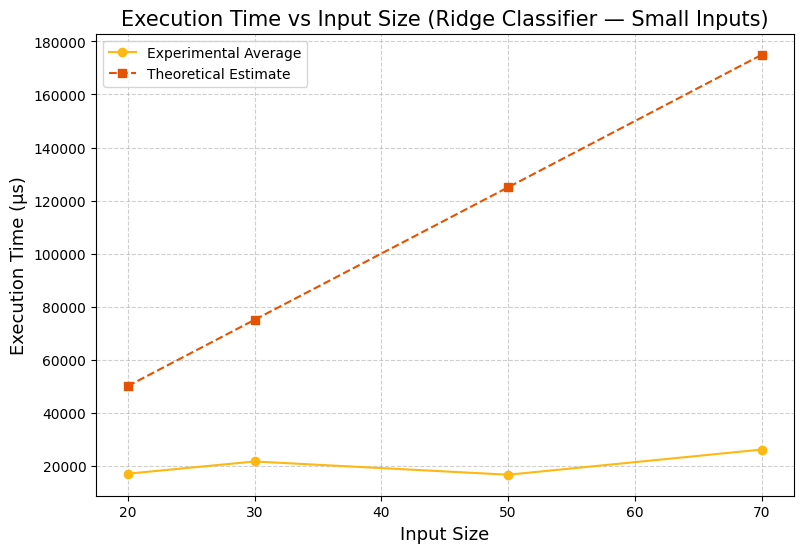

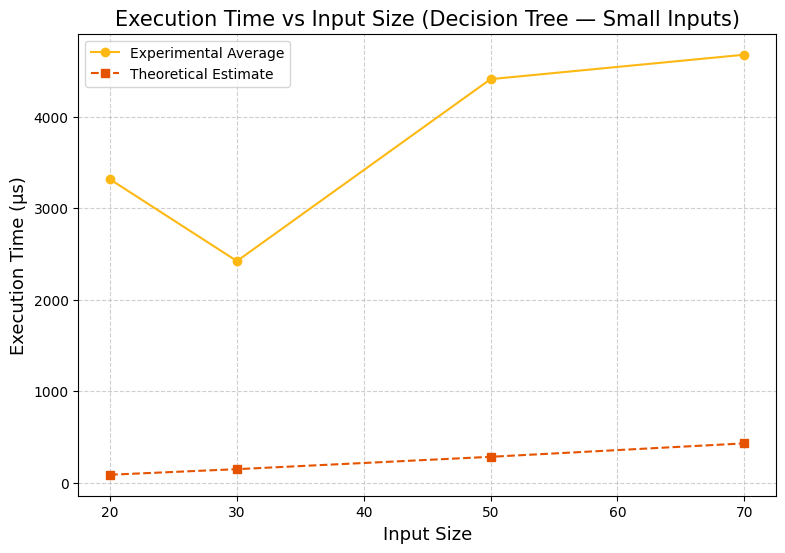

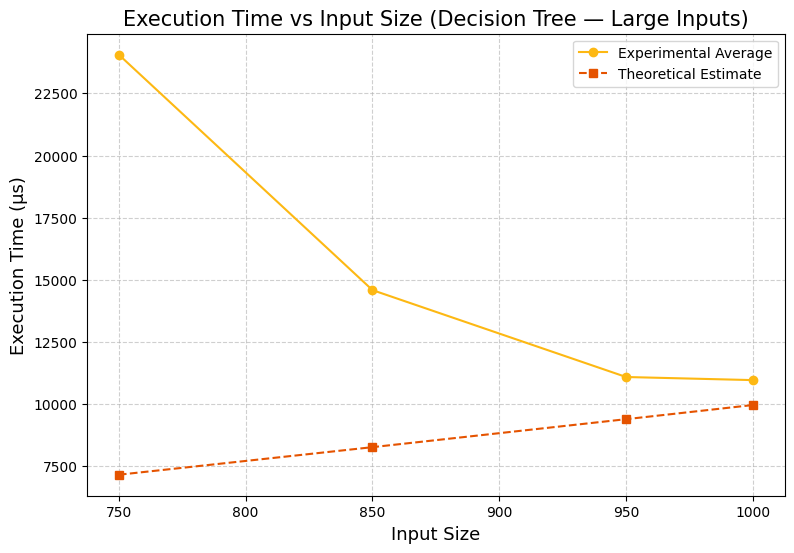

In [ ]:
import matplotlib.pyplot as plt

def plot_exp_vs_theory(df, title, xlabel, ylabel="Execution Time (µs)"):
    plt.figure(figsize=(9,6))

    # Experimental Average
    plt.plot(
        df["Input Size (n)"],
        df["Experimental Average (µs)"],
        marker='o',
        color="#FDB813",
        label="Experimental Average"
    )

    # Theoretical Estimate
    plt.plot(
        df["Input Size (n)"],
        df["Theoretical Estimate (µs)"],
        marker='s',
        linestyle="--",
        color="#E55300",
        label="Theoretical Estimate"
    )

    plt.title(title, fontsize=15)
    plt.xlabel(xlabel, fontsize=13)
    plt.ylabel(ylabel, fontsize=13)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.show()

plot_exp_vs_theory(
    small_ridge_comp,
    title="Execution Time vs Input Size (Ridge Classifier — Small Inputs)",
    xlabel="Input Size"
)

plot_exp_vs_theory(
    small_tree_comp,
    title="Execution Time vs Input Size (Decision Tree — Small Inputs)",
    xlabel="Input Size"
)

plot_exp_vs_theory(
    large_tree_comp,
    title="Execution Time vs Input Size (Decision Tree — Large Inputs)",
    xlabel="Input Size"
)
